In [1]:
import numpy as np
import pandas as pd
import os
from pyproj import Proj, Transformer
from scipy.spatial.kdtree import KDTree
import datetime
np.float = float
from netCDF4 import Dataset
from scipy.stats import chisquare
import matplotlib.pyplot as plt
from scipy.stats import linregress
import glob
from matplotlib import gridspec
from statsmodels.stats.gof import chisquare_effectsize
from brokenaxes import brokenaxes
import warnings
warnings.filterwarnings("ignore")

/var/folders/_1/fh2vf5m57871c546k_sf7xr80000gn/T/ipykernel_3959/1652879132.py:5: DeprecationWarning: Please use `KDTree` from the `scipy.spatial` namespace, the `scipy.spatial.kdtree` namespace is deprecated.
  from scipy.spatial.kdtree import KDTree


In [2]:
def lonlat_to_xy(coords_1, coords_2, hemisphere, inverse=False):

    """Converts between longitude/latitude and EASE xy coordinates.
 
    Args:
        lon (float): WGS84 longitude
        lat (float): WGS84 latitude
        hemisphere (string): 'n' or 's'
        inverse (bool): if true, converts xy to lon/lat
 
    Returns:
        tuple: pair of xy or lon/lat values
    """

    EASE_Proj = {'n': 'EPSG:3408',
                 's': 'EPGS:3409'}
    
    WGS_Proj = 'EPSG:4326'
    
    for coords in [coords_1, coords_2]: assert isinstance(coords,(np.ndarray,list))

    if inverse == False: # lonlat to xy
        
        lon, lat = coords_1, coords_2
        
        transformer = Transformer.from_crs(WGS_Proj, EASE_Proj[hemisphere])
        
        x, y = transformer.transform(lat, lon)
        
        return (x, y)

    else: # xy to lonlat
        
        x, y = coords_1, coords_2
        
        transformer = Transformer.from_crs(EASE_Proj[hemisphere], WGS_Proj)
        
        lat, lon = transformer.transform(x, y)
        
        return (lon, lat)

In [3]:
radius = 100 # 100km radius
r = int(radius/25)

datapath_sit = '/Users/carmennab/Dropbox/pb_new/data/SIT/CS2SMOS/'
datapath_sic = '/Users/carmennab/Dropbox/pb_new/data/SIC/'
datapath_sr= '/Users/carmennab/Dropbox/pb_new/data/roughness/daily_mean_roughness/25km_ease/'

### load bear data 

In [4]:
datapath = '/Users/carmennab/Dropbox/pb_new/data/bears/'

collars_df = pd.read_csv(f'{datapath}collars_combined_ease.csv',usecols=['longitude','latitude','date','ID'])
eartags_df = pd.read_csv(f'{datapath}eartags_combined_ease.csv',usecols=['longitude','latitude','date','ID'])

combined_df = pd.concat([collars_df,eartags_df])

In [5]:
combined_df['datetime'] = [datetime.datetime.strptime(date, '%Y-%m-%d') for date in combined_df['date']]

In [6]:
info = pd.read_csv(f'{datapath}collar_info.csv',usecols=['Bear','Sex','Age']).dropna()

sex = [] ; age = []

for ID in combined_df['ID']:
    try:
        a = info[info['Bear']==ID]['Age'].iloc[0]
    except:
        a = np.nan
    
    try:
        s = info[info['Bear']==ID]['Sex'].iloc[0]
    except: s = np.nan
    
    sex.append(s) ; age.append(a)

combined_df['sex'] = sex ; combined_df['age'] = age

In [7]:
### group 1 = adult females, group 2 = adult males, group 3 = subadult
group = []
for age, sex in zip(combined_df['age'],combined_df['sex']):
    if (age == 'Adult') & (sex == 'F'):
        group.append(1)
    elif (age == 'Adult') & (sex == 'M'):
        group.append(2)
    elif (age == 'Subadult'):
        group.append(3)
    else:
        group.append(np.nan)
        
combined_df['group'] = group

In [8]:
combined_df['month'] = [date.month for date in combined_df['datetime']]

In [9]:
datapath_aux = '/Users/carmennab/Dropbox/pb_new/auxiliary/'
ease_lons = np.load(f'{datapath_aux}lon_cent.npy')
ease_lats = np.load(f'{datapath_aux}lat_cent.npy')

# convert into x,y:
ease_x, ease_y = lonlat_to_xy(ease_lons,ease_lats,hemisphere='n')

# create KDTree to find EASE grid cell closest to buoy:
tree = KDTree(list(zip(ease_x.ravel(),ease_y.ravel())))

xs,ys = lonlat_to_xy(np.array(combined_df['longitude']),np.array(combined_df['latitude']),hemisphere='n')
combined_df['ind2d'] = [np.unravel_index(tree.query([x,y])[1], (ease_lats.shape[0],ease_lats.shape[1])) for x,y in zip(xs,ys)]

In [10]:
combined_df = combined_df.dropna()
combined_df

,ID,date,longitude,latitude,datetime,sex,age,group,month,ind2d
0,X11940,2010-09-08,-93.405290,58.420014,2010-09-08,F,Adult,1.0,9,"(69, 46)"
1,X11940,2010-09-08,-93.405375,58.420014,2010-09-08,F,Adult,1.0,9,"(69, 46)"
2,X11940,2010-09-08,-93.405375,58.420100,2010-09-08,F,Adult,1.0,9,"(69, 46)"
3,X11940,2010-09-08,-93.405375,58.420014,2010-09-08,F,Adult,1.0,9,"(69, 46)"
4,X11940,2010-09-09,-93.405375,58.420014,2010-09-09,F,Adult,1.0,9,"(69, 46)"
...,...,...,...,...,...,...,...,...,...,...
75387,X16947,2022-01-01,-85.251000,58.492000,2022-01-01,M,Adult,2.0,1,"(49, 46)"
75388,X16947,2022-01-02,-85.210000,58.435000,2022-01-02,M,Adult,2.0,1,"(49, 46)"
75389,X16947,2022-01-02,-84.889000,58.479000,2022-01-02,M,Adult,2.0,1,"(49, 47)"
75390,X16947,2022-01-13,-82.382000,57.825000,2022-01-13,M,Adult,2.0,1,"(42, 44)"


### functions to find environmental data within 100km of any bear

In [11]:
monthly_snows = [] ; monthly_sits = [] ; monthly_sics = []

for month in np.arange(1,13):
    snows_a = [] ; sits_a = [] ; sics_a = []
    month_df = combined_df[combined_df['month']==month]
    for date in set(month_df['datetime']):
        date_df = month_df[month_df['datetime']==date]
        str_date = date.strftime('%Y%m%d')
        filepath_sit = f'{datapath_sit}{date.year}/{str_date}.nc'
        if os.path.exists(filepath_sit) == True:  
            file = Dataset(filepath_sit)
            sits = np.array(file['sea_ice_thickness'])
            snows = np.array(file['snow_depth'])
    
            for ind2d in set(date_df['ind2d']):
                for sn in snows[ind2d[0]-r:ind2d[0]+(r+1),ind2d[1]-r:ind2d[1]+(r+1)].ravel():
                    if ~np.isnan(sn):
                        snows_a.append(sn)
                for si in sits[ind2d[0]-r:ind2d[0]+(r+1),ind2d[1]-r:ind2d[1]+(r+1)].ravel():
                    if ~np.isnan(si):
                        sits_a.append(si)

        filepath_sic = f'{datapath_sic}{date.year}/{str_date}.nc'
        if os.path.exists(filepath_sic) == True: 
            file = Dataset(filepath_sic)
            sics = np.array(file['sic'])
            sics[sics>1] = 1
            for ind2d in set(date_df['ind2d']):
                for si in sics[ind2d[0]-r:ind2d[0]+(r+1),ind2d[1]-r:ind2d[1]+(r+1)].ravel():
                    if ~np.isnan(si):
                        sics_a.append(si)

    if len(snows_a)>0:
        monthly_snows.append(snows_a)
    else:
        monthly_snows.append(np.nan)
         
    if len(sits_a)>0:
        monthly_sits.append(sits_a)
    else:
        monthly_sits.append(np.nan)
        
    if len(sics_a)>0:
        monthly_sics.append(np.multiply(sics_a,100))
    else:
        monthly_sics.append(np.nan)

### functions to load environmental data for chi-square

In [12]:
### get used and available SIT & SD and place into 0.1m & 0.05m classes

def get_sit_sd():
    
    ### load used and available SITs
    used_sits = [] ; available_sits = [] ; used_sds = [] ; available_sds = [] 
 
    for date, ind2d in zip(month_df['datetime'],month_df['ind2d']):
        str_date = date.strftime('%Y%m%d')
        filepath_sit = f'{datapath_sit}{date.year}/{str_date}.nc'
        if os.path.exists(filepath_sit) == True:  
            file = Dataset(filepath_sit)
            sits = np.array(file['sea_ice_thickness'])
            available_sits.append(sits[ind2d[0]-r:ind2d[0]+(r+1),ind2d[1]-r:ind2d[1]+(r+1)]) 
            used_sits.append(sits[ind2d])    
            sds = np.array(file['snow_depth'])
            available_sds.append(sds[ind2d[0]-r:ind2d[0]+(r+1),ind2d[1]-r:ind2d[1]+(r+1)]) 
            used_sds.append(sds[ind2d])          

        else:
            used_sits.append(np.nan) 
            available_sits.append(np.full(((r*2)+1,(r*2)+1),np.nan))
            used_sds.append(np.nan) 
            available_sds.append(np.full(((r*2)+1,(r*2)+1),np.nan))

    month_df['used_sits'] = used_sits
    month_df['available_sits'] = available_sits
    month_df['used_sds'] = used_sds
    month_df['available_sds'] = available_sds

    ### classify SITS
    bins = [0, 0.1, 0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1,1.1,1.2,1.3,1.4,1.5,1.6,1.7,1.8,1.9,2,2.1,2.2,
            2.3,2.4,2.5,2.6,2.7,2.8,2.9,3,np.inf]

    sit_names = bins[:-1]

    month_df['sit_class_used'] = pd.cut(month_df['used_sits'], bins, labels=sit_names)

    sit_class_available = []
    for sits in month_df['available_sits']:
        classed = pd.cut(sits.flatten(), bins, labels=sit_names)
        sit_class_available.append(classed)

    month_df['sit_class_available'] = sit_class_available
    
    ### classify snow depths
    bins = [0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, np.inf]

    snow_names = bins[:-1]

    month_df['snow_class_used'] = pd.cut(month_df['used_sds'], bins, labels=snow_names)

    snow_class_available = []
    for snows in month_df['available_sds']:
        classed = pd.cut(snows.flatten(), bins, labels=snow_names)
        snow_class_available.append(classed)

    month_df['snow_class_available'] = snow_class_available

In [13]:
### get used and available SIC and place into 0.1 m classes

def get_sic():
    
    r = int(radius/25)
    ### load used and available SICs
    used_sics = [] ; available_sics = [] 

    for date, ind2d in zip(month_df['datetime'],month_df['ind2d']):
        str_date = date.strftime('%Y%m%d')
        filepath_sic = f'{datapath_sic}{date.year}/{str_date}.nc'
        if os.path.exists(filepath_sic) == True:  
            sics = np.array(Dataset(filepath_sic)['sic'])
            sics[sics>1] = 1
            available_sics.append(sics[ind2d[0]-r:ind2d[0]+(r+1),ind2d[1]-r:ind2d[1]+(r+1)]) 
            used_sics.append(sics[ind2d])      
        else:
            used_sics.append(np.nan) 
            available_sics.append(np.full(((r*2)+1,(r*2)+1),np.nan))

    month_df['used_sics'] = used_sics
    month_df['available_sics'] = available_sics
    
    ### calculate value ranges 
    month_sics = [np.nan]
    for a in month_df['available_sics']:
        for b in a[~np.isnan(a)].flatten():
            month_sics.append(b)   

    ### classify SICS
    bins = [0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1]

    sic_names = bins[:-1]

    month_df['sic_class_used'] = pd.cut(month_df['used_sics'], bins, labels=sic_names)

    sic_class_available = []
    for sics in month_df['available_sics']:
        classed = pd.cut(sics.flatten(), bins, labels=sic_names)
        sic_class_available.append(classed)

    month_df['sic_class_available'] = sic_class_available

In [14]:
### get used and available SR and place into 0.01 m classes

def get_sr():
    
    r = int(radius/25)
    ### load used and available SRs
    
    used_srs = [] ; available_srs = [] 

    for date, ind2d in zip(month_df['datetime'],month_df['ind2d']):
        str_date = date.strftime('%Y%m%d')
        filepath_sit = f'{datapath_sr}{date.year}/{str_date}.nc'
        if os.path.exists(filepath_sit) == True:  
            srs = np.array(Dataset(filepath_sit)['roughness'])
            available_srs.append(srs[ind2d[0]-r:ind2d[0]+(r+1),ind2d[1]-r:ind2d[1]+(r+1)]) 
            used_srs.append(srs[ind2d])      
        else:
            used_srs.append(np.nan) 
            available_srs.append(np.full(((r*2)+1,(r*2)+1),np.nan))

    month_df['used_srs'] = used_srs
    month_df['available_srs'] = available_srs
    
    ### classify SRs
    bins = [0, 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1, 0.11, 0.12, 0.13, 0.14, 0.15, 0.16, 0.17,
            0.18, 0.19, 0.2, 0.21, 0.22, 0.23, 0.24, 0.25, np.inf]

    sr_names = bins[:-1]

    month_df['sr_class_used'] = pd.cut(month_df['used_srs'], bins, labels=sr_names)

    sr_class_available = []
    for srs in month_df['available_srs']:
        classed = pd.cut(srs.flatten(), bins, labels=sr_names)
        sr_class_available.append(classed)

    month_df['sr_class_available'] = sr_class_available

### Calculate Chi2 and Cohen's w

In [15]:
# degrees of freedom = (#rows - 1) / #cols 
# (len(sit_names)- 1) / 1

# https://courses.wccnet.edu/~palay/math160r/chisqtable.htm

sigs = {} # values above which p < 0.05

sigs['sit'] = 43.773 
sigs['sic'] = 16.919
sigs['sr'] = 37.652 
sigs['snow'] = 26.296

In [16]:
chi2_group = [] ; cohens_group = [] ; res_group = []

for group in [1,2,3]:
    group_data = combined_df[combined_df['group']==group]
    chi2_all = {} ; cohens_all = {}  ; res_all = {}
    for variable in ['sit','snow','sr','sic']:
        chi2s = [] ; cohens = [] ; res = []
        for month in np.arange(1,13):
            month_df = group_data[(np.isin(group_data['month'],month))]
            get_sit_sd()
            get_sic()
            get_sr()
            
            used = month_df[f'{variable}_class_used']
            
            if used.isnull().values.all():
                chi2s.append(np.nan)
                cohens.append(np.nan)  
                res.append(np.nan)  
            else:

                available = np.hstack(month_df[f'{variable}_class_available'])
                
                counts_used = used.value_counts().sort_index()
                counts_available = []
                for c in counts_used.index:
                    counts_available.append(len(available[available==c]))
                
                total_available = np.sum(counts_available)
                total_used = np.sum(counts_used)

                observed = (counts_used/total_used) * total_used
                expected = ((counts_available/total_available) * total_used)[:len(observed)]   

                ### calculate chi2
                chi2 = np.nansum([(((obs-exp)**2)/exp) for obs, exp in zip(observed, expected)])

                ### calculate Cohen's W
                k = len(observed)
                n = total_used
                expProps = [1/k] * k
                myProps = observed
                w = chisquare_effectsize(expProps,myProps)
                
                ### keep only stat sig results
                if (w > 0.5) & (chi2 > sigs[variable]):
                    residuals = np.array((observed - expected) / np.sqrt(expected))
                    x = np.arange(0,len(residuals))
                    y = residuals
                    mask = np.where(~np.isnan(y))
                    slope = linregress(x[mask], y[mask])[0]
                    cohens.append(w) ; chi2s.append(chi2) ; res.append(slope)

                else:
                    cohens.append(np.nan) ; chi2s.append(np.nan) ; res.append(np.nan)
 
        chi2_all[variable] = chi2s
        cohens_all[variable] = cohens
        res_all[variable] = res
        
    chi2_group.append(chi2_all) ; cohens_group.append(cohens_all) ; res_group.append(res_all) 

### plot figure

In [17]:
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

In [18]:
figpath = '/Users/carmennab/Dropbox/Apps/Overleaf/CRiceS_PolarBears_HB/figures/'

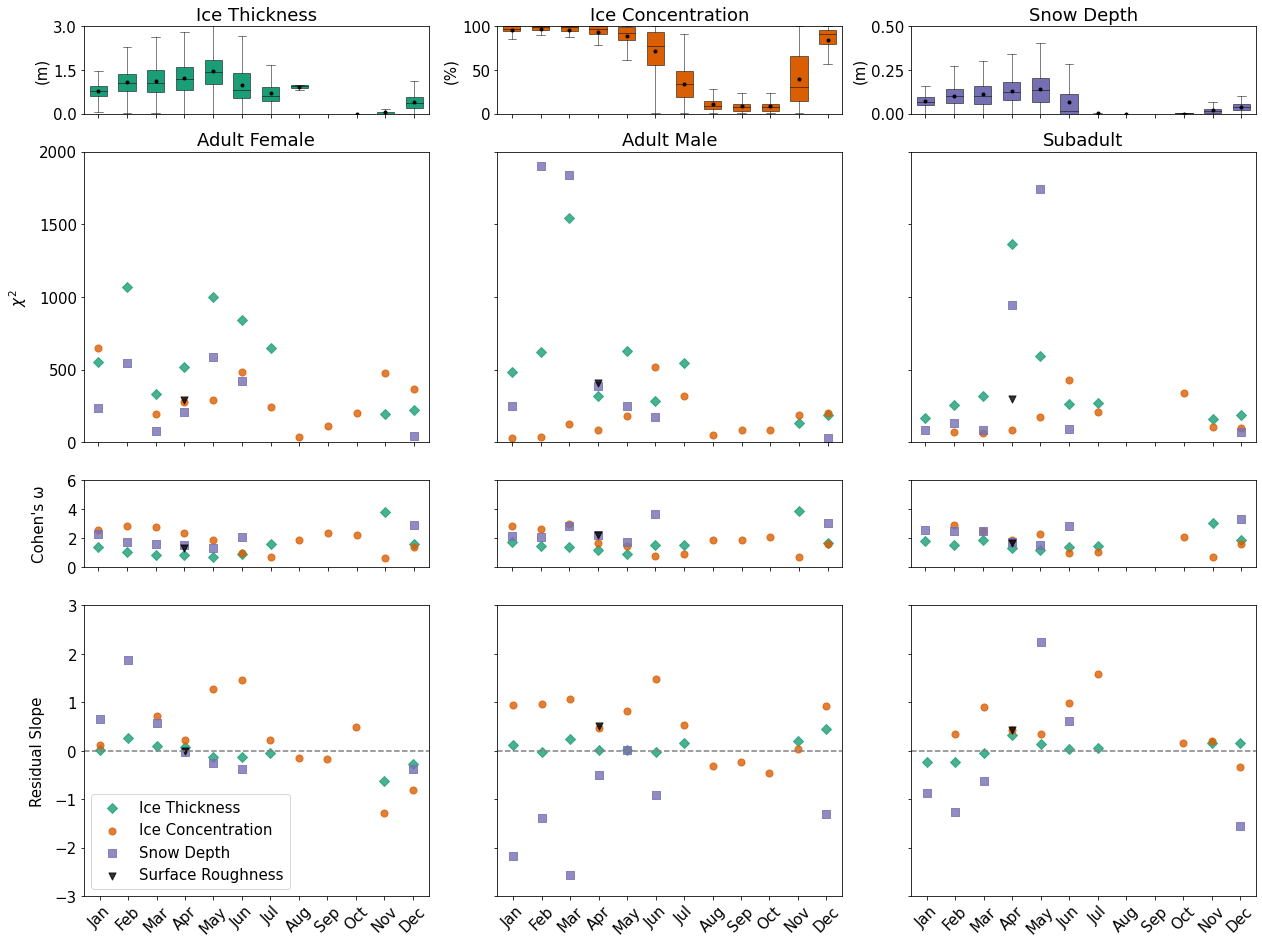

In [19]:
titles = ['Adult Female', 'Adult Male', 'Subadult']
variables = ['sit','sic','snow','sr']
# v_colors = ['#e41a1c','#377eb8','#4daf4a','k']
v_colors = ['#1b9e77','#d95f02','#7570b3','k']
v_names = ['Ice Thickness','Ice Concentration','Snow Depth','Surface Roughness']
v_markers = ['D','o','s','v']
a_ys = [3,100,0.5]
mean_units = ['(m)','(%)','(m)']

spec = gridspec.GridSpec(ncols=3, nrows=4,hspace=0.2,wspace=0.2,height_ratios=[1.5,5,1.5,5])
fig = plt.figure(figsize=(21,16))
plt.rcParams.update({'font.size': 15})

### mean values
for c,var in enumerate([monthly_sits,monthly_sics,monthly_snows]):
    ax = fig.add_subplot(spec[c])
    box = ax.boxplot(var, positions = np.arange(1,13),widths=0.6, patch_artist=True,
            showfliers=False, showmeans = True,
            medianprops={"color": "black", "linewidth": 0.5},
            meanprops={"markerfacecolor": "black","markeredgecolor": "black", "marker": 'o',"markersize":'3'},
            boxprops={"facecolor": v_colors[c], "edgecolor": "black",
                      "linewidth": 0.5},
            whiskerprops={"color": "black", "linewidth": 0.5},
            capprops={"color": "black", "linewidth": 0.5})
    
    ax.set_xticklabels([])
    ax.set_xlim([0.5,12.5])
    ax.set_ylim([0,a_ys[c]])
    ax.set_yticks([0,a_ys[c]/2,a_ys[c]])
    ax.set_ylabel( mean_units[c])
    ax.set_title(v_names[c])

### chi-square
for c,group in enumerate([1,2,3]):
    chi2_all = chi2_group[c]
    ax = fig.add_subplot(spec[c+3])
    for var,col,mar,lab in zip(variables,v_colors,v_markers,v_names):
        ax.scatter(np.arange(1,13),chi2_all[var],c=col,marker=mar,label=lab,s=50,alpha=0.8)
    
    ax.set_xticks(np.arange(1,13))
    ax.set_xticklabels([])
    ax.set_xlim([0.5,12.5])
    ax.set_ylim([0,2000])
    ax.set_yticks([0,500,1000,1500,2000])
    
    if c == 0:
        ax.set_ylabel('$\u03C7^2$',labelpad=10)

    ax.set_title(titles[c])
    if c > 0:
        ax.set_yticklabels([])
    ax.set_xticks(np.arange(1,13))

### cohen's w
for c,group in enumerate([1,2,3]):
    cohens_all = cohens_group[c]
    ax = fig.add_subplot(spec[c+6])
    
    for var,col,mar,lab in zip(variables,v_colors,v_markers,v_names):
        ax.scatter(np.arange(1,13),cohens_all[var],c=col,marker=mar,label=lab,s=50,alpha=0.8)
    ax.set_xticks(np.arange(1,13))
    ax.set_xticklabels([])
    if c == 0:
        ax.set_ylabel("Cohen's \u03C9",labelpad=20)
    ax.set_ylim([0,6])
    if c > 0:
        ax.set_yticklabels([])
    ax.set_yticks([0,2,4,6])
    ax.set_xlim([0.5,12.5])
    
### residuals
for c,group in enumerate([1,2,3]):
    res_all = res_group[c]
    ax = fig.add_subplot(spec[c+9])
    
    for var,col,mar,lab in zip(variables,v_colors,v_markers,v_names):
        ax.scatter(np.arange(1,13),res_all[var],c=col,marker=mar,label=lab,s=50,alpha=0.8)
    ax.set_xticks(np.arange(1,13))
    ax.set_xticklabels(month_names,rotation=45)
    if c == 0:
        ax.set_ylabel("Residual Slope",labelpad=10)
    ax.set_ylim([-3,3])
    if c > 0:
        ax.set_yticklabels([])
    ax.axhline(0,c='grey',linestyle='--')
    if c == 0:
        ax.legend(loc='lower left',ncol=1)
    
plt.savefig(f'{figpath}chi-square.jpg',bbox_inches = "tight", dpi = 400)